# Stock Price Movement Prediction Using Hybrid LSTM-Transformer

**Module:** CMP-L016 — Deep Learning Applications  
**Milestone:** 2 — Data Preparation, Model Definition & Training  
**Dataset:** [S&P 500 Index Stocks (Daily Updated)](https://www.kaggle.com/datasets/joebeachcapital/s-and-p500-index-stocks-daily-updated)

---


## Cell 1 — Install & Import Dependencies


In [1]:
# Run this cell first in Colab to install any missing packages.

# !pip install kaggle pandas numpy scikit-learn torch matplotlib seaborn tqdm

import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from collections import defaultdict

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.model_selection import TimeSeriesSplit

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## Cell 2 — Configuration (Hyperparameters & Paths)


In [2]:
class Config:
    """Central configuration for the entire pipeline."""

    # ── Data ──────────────────────────────────────────────────────────────
    DATA_DIR        = "./data"               # Directory containing CSV files
    MIN_HISTORY     = 1260                   # Minimum rows per ticker (~5 years)
    TICKERS         = None                   # None = use all available tickers
    MAX_TICKERS     = 50                     # Cap for faster experimentation
    WINDOW_SIZE     = 30                     # Look-back window (trading days)
    TRAIN_RATIO     = 0.70
    VAL_RATIO       = 0.15
    # test_ratio = 1 - train - val = 0.15

    # ── Features ──────────────────────────────────────────────────────────
    OHLCV_COLS      = ["Open", "High", "Low", "Close", "Volume"]
    TECHNICAL_FEATURES = True               # Include RSI, MACD, BB, EMA, ATR

    # ── Model ─────────────────────────────────────────────────────────────
    INPUT_DIM       = 12                     # Updated automatically after feature engineering
    LSTM_HIDDEN     = 128
    LSTM_LAYERS     = 2
    LSTM_DROPOUT    = 0.3
    N_HEADS         = 4
    TRANSFORMER_LAYERS = 2
    TRANSFORMER_DIM = 128
    TRANSFORMER_DFF = 256
    TRANSFORMER_DROPOUT = 0.1
    FC_HIDDEN       = 64
    OUTPUT_DIM      = 1                      # Binary classification

    # ── Training ──────────────────────────────────────────────────────────
    BATCH_SIZE      = 64
    EPOCHS          = 60
    LEARNING_RATE   = 1e-3
    WEIGHT_DECAY    = 1e-4
    PATIENCE        = 10                     # Early stopping patience
    LR_PATIENCE     = 5                      # ReduceLROnPlateau patience
    GRAD_CLIP       = 1.0                    # Gradient clipping max norm

    # ── Logging ───────────────────────────────────────────────────────────
    CHECKPOINT_PATH = "best_model.pt"


cfg = Config()
print("Configuration loaded.")
print(f"  Window size : {cfg.WINDOW_SIZE} days")
print(f"  Batch size  : {cfg.BATCH_SIZE}")
print(f"  Epochs      : {cfg.EPOCHS}")
print(f"  LR          : {cfg.LEARNING_RATE}")


Configuration loaded.
  Window size : 30 days
  Batch size  : 64
  Epochs      : 60
  LR          : 0.001


## Cell 3 — Data Loading


In [3]:
# Dataset: S&P 500 Index Stocks (Daily Updated) by JoeBeachCapital on Kaggle
# Link   : https://www.kaggle.com/datasets/joebeachcapital/s-and-p500-index-stocks-daily-updated
#
# Instructions for Colab:
#   Option A (Kaggle API):
#       !pip install kaggle
#       !mkdir ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
#       !kaggle datasets download -d joebeachcapital/s-and-p500-index-stocks-daily-updated
#       !unzip s-and-p500-index-stocks-daily-updated.zip -d ./data
#
#   Option B (Google Drive):
#       from google.colab import drive
#       drive.mount('/content/drive')
#       DATA_DIR = '/content/drive/MyDrive/sp500_data'


def load_sp500_data(data_dir: str, max_tickers: int = None) -> dict:
    """
    Load individual ticker CSV files from data_dir.

    Each CSV is expected to have columns:
        Date, Open, High, Low, Close, Volume  (and optionally Adj Close)

    Returns
    -------
    dict : {ticker_symbol: pd.DataFrame}
    """
    csv_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]
    if max_tickers:
        csv_files = csv_files[:max_tickers]

    data = {}
    for fname in csv_files:
        ticker = fname.replace(".csv", "").upper()
        path = os.path.join(data_dir, fname)
        try:
            df = pd.read_csv(path, parse_dates=["Date"])
            df = df.sort_values("Date").reset_index(drop=True)

            # Standardise column names
            df.columns = [c.strip().title().replace(" ", "_") for c in df.columns]
            if "Date" not in df.columns:
                continue

            # Keep only needed columns
            cols_needed = ["Date"] + [c for c in cfg.OHLCV_COLS if c in df.columns]
            if len(cols_needed) < 6:           # Need all OHLCV
                continue

            df = df[cols_needed].dropna(subset=cfg.OHLCV_COLS)
            df = df[df["Close"] > 0]           # Remove zero/negative prices

            if len(df) >= cfg.MIN_HISTORY:
                data[ticker] = df
        except Exception:
            continue

    print(f"Loaded {len(data)} tickers with ≥{cfg.MIN_HISTORY} rows each.")
    return data


# ── Run loading ──────────────────────────────────────────────────────────────
# NOTE: Replace DATA_DIR with your actual path before running.
# For demonstration / offline testing, we generate synthetic data below.

USE_SYNTHETIC = not os.path.isdir(cfg.DATA_DIR)

if USE_SYNTHETIC:
    print("⚠ Data directory not found — generating synthetic S&P 500-like data for demonstration.")

    def generate_synthetic_ticker(n_days=1500, seed=0) -> pd.DataFrame:
        rng = np.random.default_rng(seed)
        dates = pd.date_range("2018-01-02", periods=n_days, freq="B")
        log_returns = rng.normal(0.0003, 0.012, n_days)
        close = 100.0 * np.exp(np.cumsum(log_returns))
        high  = close * (1 + rng.uniform(0, 0.015, n_days))
        low   = close * (1 - rng.uniform(0, 0.015, n_days))
        open_ = low + (high - low) * rng.uniform(0, 1, n_days)
        volume = rng.integers(500_000, 5_000_000, n_days).astype(float)
        return pd.DataFrame({"Date": dates, "Open": open_, "High": high,
                              "Low": low, "Close": close, "Volume": volume})

    raw_data = {f"SYN{i:02d}": generate_synthetic_ticker(seed=i) for i in range(30)}
else:
    raw_data = load_sp500_data(cfg.DATA_DIR, max_tickers=cfg.MAX_TICKERS)

print(f"\nSample tickers: {list(raw_data.keys())[:5]}")
sample_ticker = list(raw_data.keys())[0]
print(raw_data[sample_ticker].tail(3).to_string(index=False))


⚠ Data directory not found — generating synthetic S&P 500-like data for demonstration.

Sample tickers: ['SYN00', 'SYN01', 'SYN02', 'SYN03', 'SYN04']
      Date       Open       High        Low      Close    Volume
2023-09-28 122.411714 122.423110 121.412144 122.061764  616904.0
2023-09-29 119.206670 120.408352 118.536579 119.959637 3702075.0
2023-10-02 119.858066 120.077790 119.413706 119.426536 1473679.0


## Cell 4 — Exploratory Data Analysis (EDA)


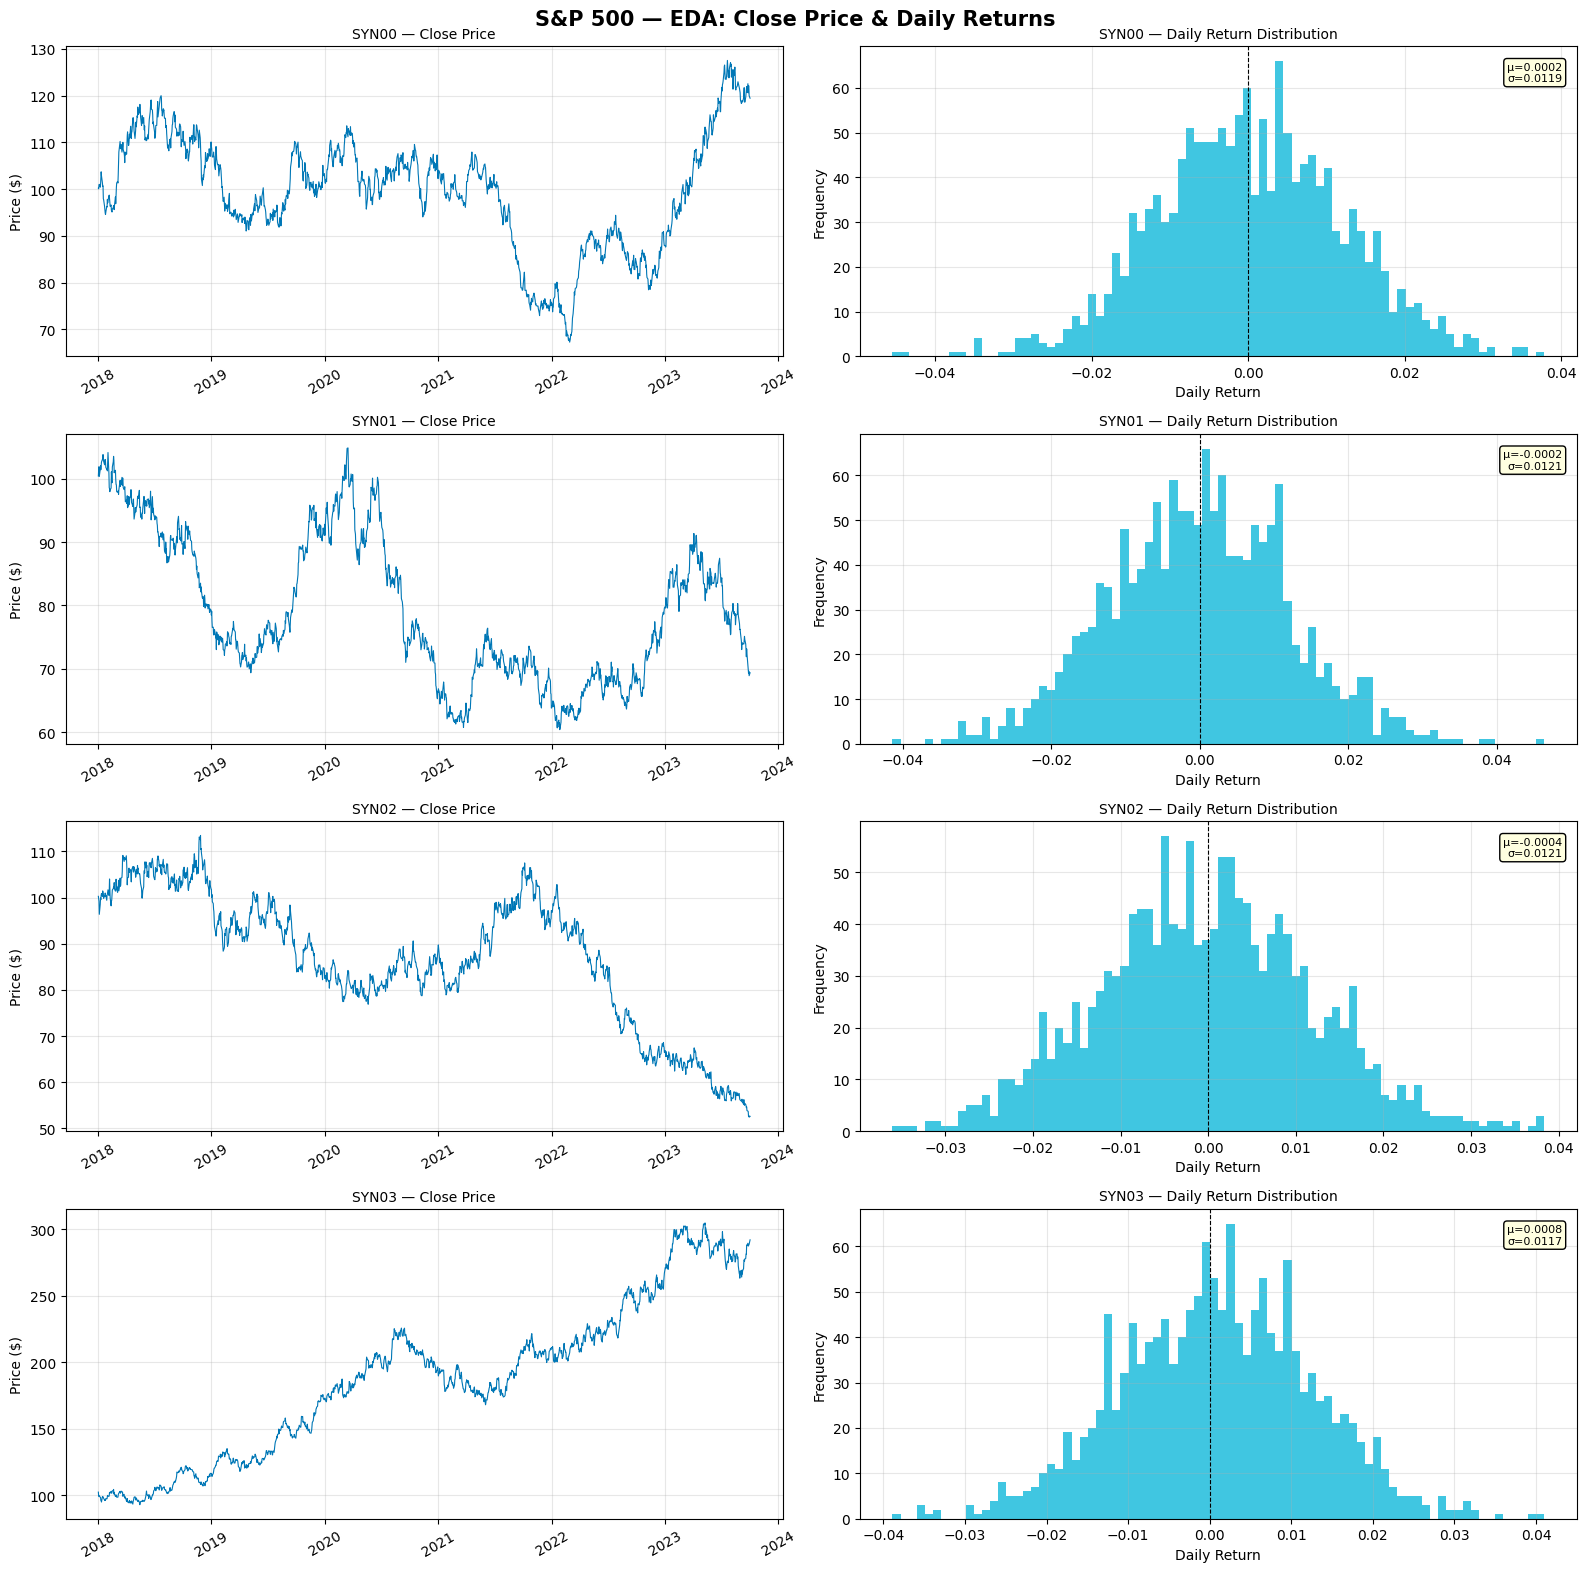

EDA chart saved → eda_overview.png

── Dataset Summary ──────────────────────────────
       N Rows  Missing Close  Zero Volume
count    30.0           30.0         30.0
mean   1500.0            0.0          0.0
std       0.0            0.0          0.0
min    1500.0            0.0          0.0
25%    1500.0            0.0          0.0
50%    1500.0            0.0          0.0
75%    1500.0            0.0          0.0
max    1500.0            0.0          0.0

Total tickers : 30
Total rows    : 45,000


In [4]:
def plot_eda(data: dict, n_tickers: int = 4):
    tickers = list(data.keys())[:n_tickers]
    fig, axes = plt.subplots(n_tickers, 2, figsize=(16, 4 * n_tickers))
    fig.suptitle("S&P 500 — EDA: Close Price & Daily Returns", fontsize=15, fontweight="bold")

    for i, ticker in enumerate(tickers):
        df = data[ticker].copy()
        df["Return"] = df["Close"].pct_change()

        # Close price
        ax1 = axes[i, 0]
        ax1.plot(df["Date"], df["Close"], linewidth=0.8, color="#0077B6")
        ax1.set_title(f"{ticker} — Close Price", fontsize=10)
        ax1.set_ylabel("Price ($)")
        ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax1.tick_params(axis="x", rotation=30)
        ax1.grid(alpha=0.3)

        # Return distribution
        ax2 = axes[i, 1]
        returns = df["Return"].dropna()
        ax2.hist(returns, bins=80, color="#00B4D8", edgecolor="none", alpha=0.75)
        ax2.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax2.set_title(f"{ticker} — Daily Return Distribution", fontsize=10)
        ax2.set_xlabel("Daily Return")
        ax2.set_ylabel("Frequency")
        ax2.grid(alpha=0.3)

        # Annotate stats
        stats = f"μ={returns.mean():.4f}\nσ={returns.std():.4f}"
        ax2.text(0.98, 0.95, stats, transform=ax2.transAxes,
                 va="top", ha="right", fontsize=8,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

    plt.tight_layout()
    plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("EDA chart saved → eda_overview.png")


plot_eda(raw_data, n_tickers=min(4, len(raw_data)))


def summarise_dataset(data: dict):
    rows = []
    for ticker, df in data.items():
        rows.append({
            "Ticker"       : ticker,
            "Start Date"   : df["Date"].min().date(),
            "End Date"     : df["Date"].max().date(),
            "N Rows"       : len(df),
            "Missing Close": df["Close"].isna().sum(),
            "Zero Volume"  : (df["Volume"] == 0).sum(),
        })
    summary = pd.DataFrame(rows)
    print("\n── Dataset Summary ──────────────────────────────")
    print(summary.describe().to_string())
    print(f"\nTotal tickers : {len(summary)}")
    print(f"Total rows    : {summary['N Rows'].sum():,}")
    return summary


dataset_summary = summarise_dataset(raw_data)


## Cell 5 — Data Cleaning & Preprocessing


In [5]:
def clean_ticker(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean a single ticker DataFrame:
      1. Sort by date
      2. Forward-fill short gaps (≤ 3 days) in price columns
      3. Drop rows with remaining NaN in OHLCV
      4. Remove duplicated dates
      5. Cap outlier returns at ±30% (fat-finger / data error guard)
    """
    df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

    # Forward-fill small gaps
    for col in cfg.OHLCV_COLS:
        df[col] = df[col].ffill(limit=3)

    # Drop remaining NaNs
    df = df.dropna(subset=cfg.OHLCV_COLS).reset_index(drop=True)

    # Cap extreme single-day returns (data errors, not genuine moves)
    returns = df["Close"].pct_change()
    mask = returns.abs() > 0.30
    if mask.any():
        df.loc[mask, "Close"] = df["Close"].shift(1)[mask]  # replace with previous close
        df.loc[mask, "High"]  = df["Close"][mask]
        df.loc[mask, "Low"]   = df["Close"][mask]
        df.loc[mask, "Open"]  = df["Close"][mask]

    return df


def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add 7 widely-used technical indicators as additional input features.

    Features added
    ──────────────
    RSI_14      : Relative Strength Index (14-day)
    MACD        : MACD line (EMA12 - EMA26)
    MACD_Signal : 9-day EMA of MACD
    BB_Upper    : Bollinger Band upper (20-day, 2σ)
    BB_Lower    : Bollinger Band lower (20-day, 2σ)
    EMA_20      : Exponential Moving Average (20-day)
    ATR_14      : Average True Range (14-day) — volatility proxy
    """
    close  = df["Close"]
    high   = df["High"]
    low    = df["Low"]

    # ── RSI ──────────────────────────────────────────────────────────────
    delta  = close.diff()
    gain   = delta.clip(lower=0)
    loss   = (-delta).clip(lower=0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    rs     = avg_gain / (avg_loss + 1e-9)
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # ── MACD ─────────────────────────────────────────────────────────────
    ema12  = close.ewm(span=12, adjust=False).mean()
    ema26  = close.ewm(span=26, adjust=False).mean()
    df["MACD"]        = ema12 - ema26
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    # ── Bollinger Bands ──────────────────────────────────────────────────
    ma20   = close.rolling(20).mean()
    std20  = close.rolling(20).std()
    df["BB_Upper"] = ma20 + 2 * std20
    df["BB_Lower"] = ma20 - 2 * std20

    # ── EMA 20 ───────────────────────────────────────────────────────────
    df["EMA_20"] = close.ewm(span=20, adjust=False).mean()

    # ── ATR (14) ─────────────────────────────────────────────────────────
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low  - prev_close).abs()
    ], axis=1).max(axis=1)
    df["ATR_14"] = tr.ewm(alpha=1/14, min_periods=14, adjust=False).mean()

    return df


def create_target(df: pd.DataFrame) -> pd.DataFrame:
    """
    Binary target: 1 if next-day close > today's close, else 0.
    Strictly avoids look-ahead: target uses FUTURE close, shifted backwards.
    """
    df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)
    return df


def preprocess_pipeline(data: dict) -> dict:
    """Apply full preprocessing pipeline to all tickers."""
    processed = {}
    feature_cols_set = False

    for ticker, df in data.items():
        df = clean_ticker(df)
        df = add_technical_indicators(df)
        df = create_target(df)

        # Drop NaN rows created by rolling windows and target shift
        df = df.dropna().reset_index(drop=True)

        if len(df) < cfg.MIN_HISTORY // 2:
            continue  # Skip if too little data after cleaning

        if not feature_cols_set:
            cfg.FEATURE_COLS = [c for c in df.columns
                                if c not in ("Date", "Target")]
            cfg.INPUT_DIM = len(cfg.FEATURE_COLS)
            feature_cols_set = True

        processed[ticker] = df

    print(f"\nPreprocessing complete: {len(processed)} tickers retained.")
    print(f"Feature columns ({cfg.INPUT_DIM}): {cfg.FEATURE_COLS}")
    return processed


processed_data = preprocess_pipeline(raw_data)

# ── Verify class balance ───────────────────────────────────────────────────
all_targets = pd.concat([df["Target"] for df in processed_data.values()])
vc = all_targets.value_counts(normalize=True)
print(f"\nClass balance — UP: {vc.get(1, 0):.2%}  |  DOWN: {vc.get(0, 0):.2%}")



Preprocessing complete: 30 tickers retained.
Feature columns (12): ['Open', 'High', 'Low', 'Close', 'Volume', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_Upper', 'BB_Lower', 'EMA_20', 'ATR_14']

Class balance — UP: 51.00%  |  DOWN: 49.00%


## Cell 6 — Feature Visualisation (Post-Preprocessing)


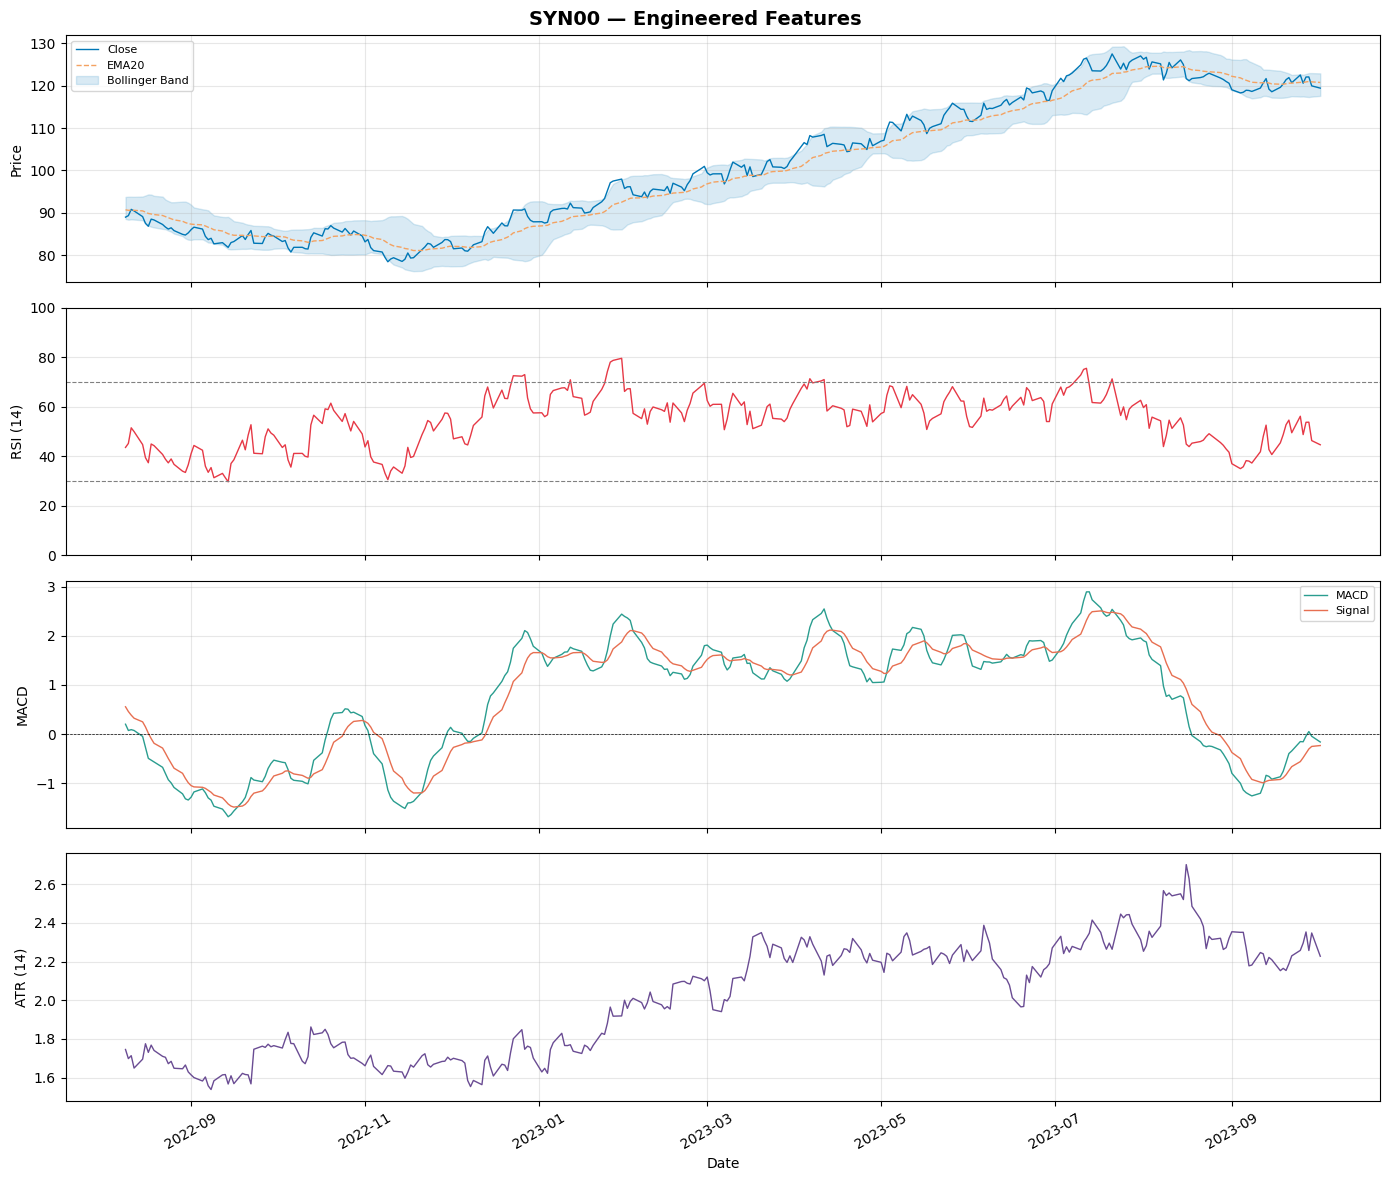

In [6]:
def plot_features(df: pd.DataFrame, ticker: str):
    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle(f"{ticker} — Engineered Features", fontsize=14, fontweight="bold")

    tail = df.tail(300)

    # Close + BB + EMA
    axes[0].plot(tail["Date"], tail["Close"], label="Close",  color="#0077B6", lw=1)
    axes[0].plot(tail["Date"], tail["EMA_20"], label="EMA20", color="#F4A261", lw=1, ls="--")
    axes[0].fill_between(tail["Date"], tail["BB_Upper"], tail["BB_Lower"],
                          alpha=0.15, color="#0077B6", label="Bollinger Band")
    axes[0].set_ylabel("Price"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    # RSI
    axes[1].plot(tail["Date"], tail["RSI_14"], color="#E63946", lw=1)
    axes[1].axhline(70, color="gray", ls="--", lw=0.8)
    axes[1].axhline(30, color="gray", ls="--", lw=0.8)
    axes[1].set_ylabel("RSI (14)"); axes[1].set_ylim(0, 100); axes[1].grid(alpha=0.3)

    # MACD
    axes[2].plot(tail["Date"], tail["MACD"],        label="MACD",   color="#2A9D8F", lw=1)
    axes[2].plot(tail["Date"], tail["MACD_Signal"], label="Signal", color="#E76F51", lw=1)
    axes[2].axhline(0, color="black", ls="--", lw=0.5)
    axes[2].set_ylabel("MACD"); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    # ATR
    axes[3].plot(tail["Date"], tail["ATR_14"], color="#6A4C93", lw=1)
    axes[3].set_ylabel("ATR (14)"); axes[3].set_xlabel("Date"); axes[3].grid(alpha=0.3)
    axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[3].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.savefig(f"features_{ticker}.png", dpi=120, bbox_inches="tight")
    plt.show()


sample_ticker = list(processed_data.keys())[0]
plot_features(processed_data[sample_ticker], sample_ticker)


## Cell 7 — Dataset & DataLoader


In [7]:
class StockSequenceDataset(Dataset):
    """
    Sliding-window dataset for time-series classification.

    Each sample: (X, y)
      X : float tensor of shape (window_size, n_features)  — normalised
      y : float tensor scalar                              — 0 or 1
    """

    def __init__(self, df: pd.DataFrame, window: int, scaler=None, fit_scaler: bool = False):
        self.window = window
        feature_data = df[cfg.FEATURE_COLS].values.astype(np.float32)
        targets       = df["Target"].values.astype(np.float32)

        # Normalise features
        if fit_scaler:
            self.scaler = MinMaxScaler()
            feature_data = self.scaler.fit_transform(feature_data)
        elif scaler is not None:
            self.scaler = scaler
            feature_data = self.scaler.transform(feature_data)
        else:
            self.scaler = None

        # Build windows
        self.X, self.y = [], []
        for i in range(window, len(feature_data)):
            self.X.append(feature_data[i - window: i])
            self.y.append(targets[i])

        self.X = np.array(self.X, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.float32)

    def __len__(self):  return len(self.y)
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx])


def build_dataloaders(data: dict, cfg: Config):
    """
    Concatenate all tickers, split chronologically, return DataLoaders.
    Scaler is fit ONLY on training data to prevent leakage.
    """
    all_dfs = list(data.values())

    # Chronological split per ticker, then concatenate
    train_dfs, val_dfs, test_dfs = [], [], []

    for df in all_dfs:
        n = len(df)
        t_end = int(n * cfg.TRAIN_RATIO)
        v_end  = int(n * (cfg.TRAIN_RATIO + cfg.VAL_RATIO))
        train_dfs.append(df.iloc[:t_end])
        val_dfs.append(df.iloc[t_end:v_end])
        test_dfs.append(df.iloc[v_end:])

    train_df = pd.concat(train_dfs).reset_index(drop=True)
    val_df   = pd.concat(val_dfs).reset_index(drop=True)
    test_df  = pd.concat(test_dfs).reset_index(drop=True)

    train_set = StockSequenceDataset(train_df, cfg.WINDOW_SIZE, fit_scaler=True)
    val_set   = StockSequenceDataset(val_df,   cfg.WINDOW_SIZE, scaler=train_set.scaler)
    test_set  = StockSequenceDataset(test_df,  cfg.WINDOW_SIZE, scaler=train_set.scaler)

    print(f"\nDataset sizes — Train: {len(train_set):,}  |  Val: {len(val_set):,}  |  Test: {len(test_set):,}")

    train_loader = DataLoader(train_set, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_set,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_set,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)

    # Compute positive class weight for imbalanced loss
    pos_weight = torch.tensor(
        [(train_df["Target"] == 0).sum() / (train_df["Target"] == 1).sum()],
        dtype=torch.float32
    )
    print(f"Positive class weight (for BCEWithLogitsLoss): {pos_weight.item():.3f}")
    return train_loader, val_loader, test_loader, pos_weight


train_loader, val_loader, test_loader, pos_weight = build_dataloaders(processed_data, cfg)

# Verify a batch
Xb, yb = next(iter(train_loader))
print(f"\nSample batch — X: {Xb.shape}  y: {yb.shape}  y_mean: {yb.mean():.3f}")



Dataset sizes — Train: 31,050  |  Val: 6,630  |  Test: 6,660
Positive class weight (for BCEWithLogitsLoss): 0.969

Sample batch — X: torch.Size([64, 30, 12])  y: torch.Size([64])  y_mean: 0.641


## Cell 8 — Model Architecture: Hybrid Bidirectional LSTM + Transformer


In [8]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding for Transformer input.
    Adds temporal position information to each time step.
    """
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 500):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len).unsqueeze(1)                   # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))                      # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (batch, seq_len, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


class HybridLSTMTransformer(nn.Module):
    """
    Hybrid Bidirectional LSTM + Multi-Head Attention Transformer model.

    Architecture
    ────────────
    1. Input projection  : Linear(input_dim → lstm_hidden)
    2. Bidirectional LSTM: 2-layer BiLSTM → captures local temporal dynamics
    3. Positional Encoding: Adds positional context to LSTM output
    4. Transformer Encoder: Multi-head self-attention over the sequence
    5. Aggregation        : Mean pooling over the time dimension
    6. Classification Head: FC layers with BatchNorm, Dropout → sigmoid output

    Rationale
    ─────────
    - BiLSTM: Efficiently encodes short-horizon momentum and mean-reversion
    - Transformer: Attends to critical historical windows (e.g., earnings events)
      regardless of temporal distance — overcomes LSTM's recency bias
    - Mean pooling: Aggregates all time steps rather than using only final state
    """

    def __init__(self, cfg: Config):
        super().__init__()

        # ── Input Projection ─────────────────────────────────────────────
        self.input_proj = nn.Sequential(
            nn.Linear(cfg.INPUT_DIM, cfg.LSTM_HIDDEN),
            nn.LayerNorm(cfg.LSTM_HIDDEN),
            nn.ReLU()
        )

        # ── Bidirectional LSTM ───────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size  = cfg.LSTM_HIDDEN,
            hidden_size = cfg.LSTM_HIDDEN,
            num_layers  = cfg.LSTM_LAYERS,
            batch_first = True,
            bidirectional = True,
            dropout = cfg.LSTM_DROPOUT if cfg.LSTM_LAYERS > 1 else 0.0
        )
        lstm_out_dim = cfg.LSTM_HIDDEN * 2   # BiLSTM doubles output dim

        # Project BiLSTM output to Transformer d_model
        self.lstm_proj = nn.Linear(lstm_out_dim, cfg.TRANSFORMER_DIM)

        # ── Positional Encoding ──────────────────────────────────────────
        self.pos_enc = PositionalEncoding(cfg.TRANSFORMER_DIM,
                                          cfg.TRANSFORMER_DROPOUT)

        # ── Transformer Encoder ──────────────────────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = cfg.TRANSFORMER_DIM,
            nhead           = cfg.N_HEADS,
            dim_feedforward = cfg.TRANSFORMER_DFF,
            dropout         = cfg.TRANSFORMER_DROPOUT,
            batch_first     = True,
            norm_first      = True            # Pre-norm for training stability
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers = cfg.TRANSFORMER_LAYERS
        )

        # ── Classification Head ──────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(cfg.TRANSFORMER_DIM, cfg.FC_HIDDEN),
            nn.BatchNorm1d(cfg.FC_HIDDEN),
            nn.ReLU(),
            nn.Dropout(cfg.LSTM_DROPOUT),
            nn.Linear(cfg.FC_HIDDEN, cfg.OUTPUT_DIM)
            # No sigmoid here — BCEWithLogitsLoss handles it numerically
        )

        self._init_weights()

    def _init_weights(self):
        """Xavier / Orthogonal weight initialisation for stable training."""
        for name, param in self.named_parameters():
            if "weight" in name and param.dim() >= 2:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : (batch, seq_len, input_dim)

        Returns
        -------
        logits : (batch,)
        """
        # Input projection
        x = self.input_proj(x)                           # (B, T, lstm_hidden)

        # BiLSTM
        lstm_out, _ = self.lstm(x)                       # (B, T, lstm_hidden*2)

        # Project to Transformer dimension
        x = self.lstm_proj(lstm_out)                     # (B, T, transformer_dim)

        # Positional encoding
        x = self.pos_enc(x)                              # (B, T, transformer_dim)

        # Transformer self-attention
        x = self.transformer(x)                          # (B, T, transformer_dim)

        # Mean pooling over time
        x = x.mean(dim=1)                                # (B, transformer_dim)

        # Classification
        logits = self.classifier(x).squeeze(-1)          # (B,)
        return logits


# ── Instantiate & inspect ─────────────────────────────────────────────────
model = HybridLSTMTransformer(cfg).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel: HybridLSTMTransformer")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable:,}")

# Quick forward pass sanity check
with torch.no_grad():
    dummy = torch.randn(8, cfg.WINDOW_SIZE, cfg.INPUT_DIM).to(DEVICE)
    out   = model(dummy)
    print(f"  Test forward pass    : input {dummy.shape} → output {out.shape} ✓")



Model: HybridLSTMTransformer
  Total parameters     : 967,681
  Trainable parameters : 967,681
  Test forward pass    : input torch.Size([8, 30, 12]) → output torch.Size([8]) ✓


## Cell 9 — Training Utilities


In [9]:
class EarlyStopping:
    """Stop training when validation loss does not improve for `patience` epochs."""

    def __init__(self, patience: int = 10, delta: float = 1e-4,
                 path: str = "best_model.pt", verbose: bool = True):
        self.patience = patience
        self.delta    = delta
        self.path     = path
        self.verbose  = verbose
        self.counter  = 0
        self.best_loss = float("inf")
        self.early_stop = False

    def __call__(self, val_loss: float, model: nn.Module):
        if val_loss < self.best_loss - self.delta:
            if self.verbose:
                print(f"    ✓ Val loss improved {self.best_loss:.4f} → {val_loss:.4f}. Saving checkpoint.")
            self.best_loss = val_loss
            self.counter   = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.verbose:
                print(f"    EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True


def train_one_epoch(model, loader, optimizer, criterion, clip: float = 1.0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item() * len(y)
        preds  = (torch.sigmoid(logits) >= 0.5).long()
        correct += (preds == y.long()).sum().item()
        total   += len(y)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        loss   = criterion(logits, y)

        total_loss += loss.item() * len(y)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).long()
        correct += (preds == y.long()).sum().item()
        total   += len(y)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    acc = correct / total
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.5
    f1  = f1_score(all_labels, (np.array(all_probs) >= 0.5).astype(int), zero_division=0)
    return total_loss / total, acc, auc, f1, np.array(all_probs), np.array(all_labels)


## Cell 10 — Training Loop


In [10]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))

optimizer = optim.AdamW(
    model.parameters(),
    lr           = cfg.LEARNING_RATE,
    weight_decay = cfg.WEIGHT_DECAY
)

# Note: 'verbose' was removed from ReduceLROnPlateau in PyTorch >= 2.2
# LR changes are printed manually in the training loop instead.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5,
    patience=cfg.LR_PATIENCE
)

early_stopper = EarlyStopping(
    patience = cfg.PATIENCE,
    path     = cfg.CHECKPOINT_PATH,
    verbose  = True
)

history = defaultdict(list)

print("\n" + "="*65)
print(" Starting Training — Hybrid LSTM-Transformer")
print("="*65)

for epoch in range(1, cfg.EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, cfg.GRAD_CLIP)
    vl_loss, vl_acc, vl_auc, vl_f1, _, _ = evaluate(model, val_loader, criterion)

    prev_lr = optimizer.param_groups[0]['lr']
    scheduler.step(vl_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < prev_lr:
        print(f"    ↓ LR reduced: {prev_lr:.2e} → {new_lr:.2e}")

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_auc"].append(vl_auc)
    history["val_f1"].append(vl_f1)

    print(f"Epoch {epoch:3d}/{cfg.EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.3f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.3f}  AUC: {vl_auc:.3f}  F1: {vl_f1:.3f}")

    early_stopper(vl_loss, model)
    if early_stopper.early_stop:
        print(f"\n⛔ Early stopping triggered at epoch {epoch}.")
        break

print("\nTraining complete. Best checkpoint saved →", cfg.CHECKPOINT_PATH)



 Starting Training — Hybrid LSTM-Transformer
Epoch   1/60 | Train Loss: 0.7115  Acc: 0.498 | Val Loss: 0.6825  Acc: 0.514  AUC: 0.494  F1: 0.657
    ✓ Val loss improved inf → 0.6825. Saving checkpoint.
Epoch   2/60 | Train Loss: 0.6949  Acc: 0.504 | Val Loss: 0.6835  Acc: 0.503  AUC: 0.507  F1: 0.437
    EarlyStopping: 1/10
Epoch   3/60 | Train Loss: 0.6896  Acc: 0.499 | Val Loss: 0.6818  Acc: 0.514  AUC: 0.508  F1: 0.634
    ✓ Val loss improved 0.6825 → 0.6818. Saving checkpoint.
Epoch   4/60 | Train Loss: 0.6853  Acc: 0.498 | Val Loss: 0.6823  Acc: 0.487  AUC: 0.496  F1: 0.004
    EarlyStopping: 1/10
Epoch   5/60 | Train Loss: 0.6848  Acc: 0.497 | Val Loss: 0.6842  Acc: 0.487  AUC: 0.491  F1: 0.000
    EarlyStopping: 2/10
Epoch   6/60 | Train Loss: 0.6837  Acc: 0.503 | Val Loss: 0.6822  Acc: 0.487  AUC: 0.493  F1: 0.000
    EarlyStopping: 3/10
Epoch   7/60 | Train Loss: 0.6828  Acc: 0.503 | Val Loss: 0.6823  Acc: 0.487  AUC: 0.489  F1: 0.000
    EarlyStopping: 4/10
Epoch   8/60 | Tr

## Cell 11 — Training Curves Visualisation


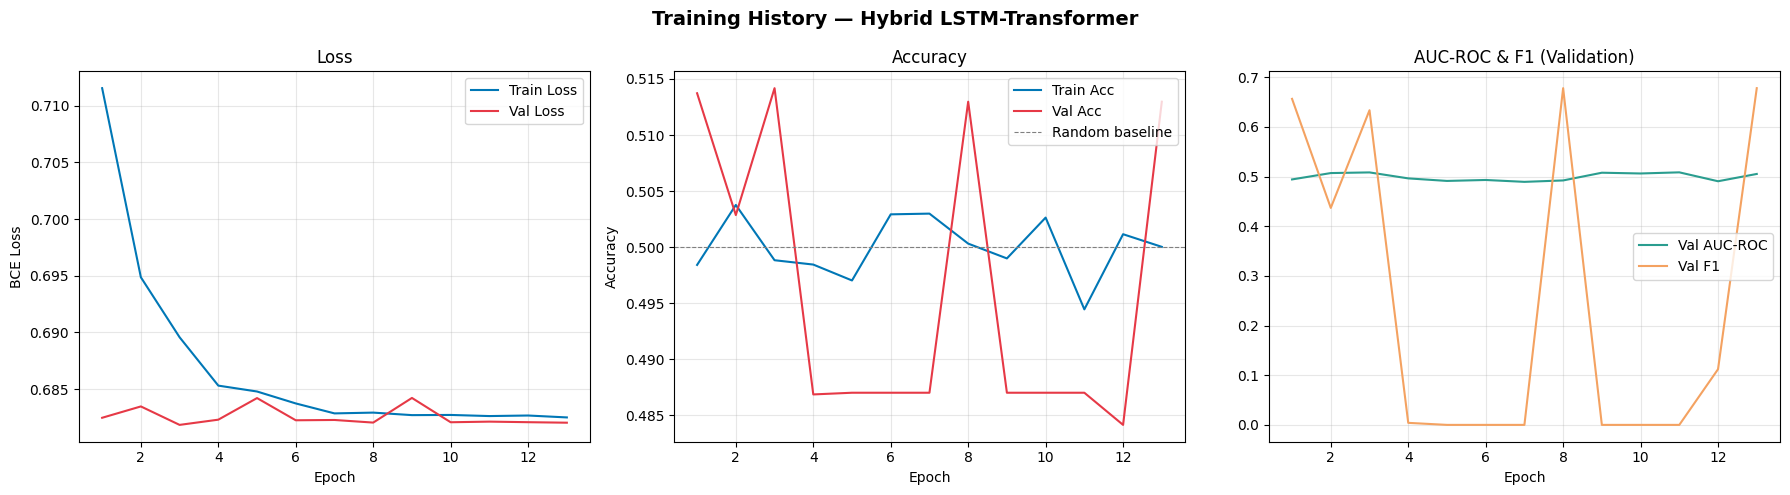

Training history saved → training_history.png


In [11]:
def plot_training_history(history: dict):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Training History — Hybrid LSTM-Transformer", fontsize=14, fontweight="bold")
    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="#0077B6")
    axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   color="#E63946")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], label="Train Acc", color="#0077B6")
    axes[1].plot(epochs, history["val_acc"],   label="Val Acc",   color="#E63946")
    axes[1].axhline(0.5, color="gray", ls="--", lw=0.8, label="Random baseline")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # AUC & F1
    axes[2].plot(epochs, history["val_auc"], label="Val AUC-ROC", color="#2A9D8F")
    axes[2].plot(epochs, history["val_f1"],  label="Val F1",      color="#F4A261")
    axes[2].set_title("AUC-ROC & F1 (Validation)"); axes[2].set_xlabel("Epoch")
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Training history saved → training_history.png")


plot_training_history(history)


## Cell 12 — Test Set Evaluation


Best model loaded from: best_model.pt

 TEST SET RESULTS
  Loss     : 0.6816
  Accuracy : 0.5209
  AUC-ROC  : 0.5138
  F1 Score : 0.6446

              precision    recall  f1-score   support

    DOWN (0)       0.51      0.18      0.26      3212
      UP (1)       0.52      0.84      0.64      3448

    accuracy                           0.52      6660
   macro avg       0.52      0.51      0.45      6660
weighted avg       0.52      0.52      0.46      6660



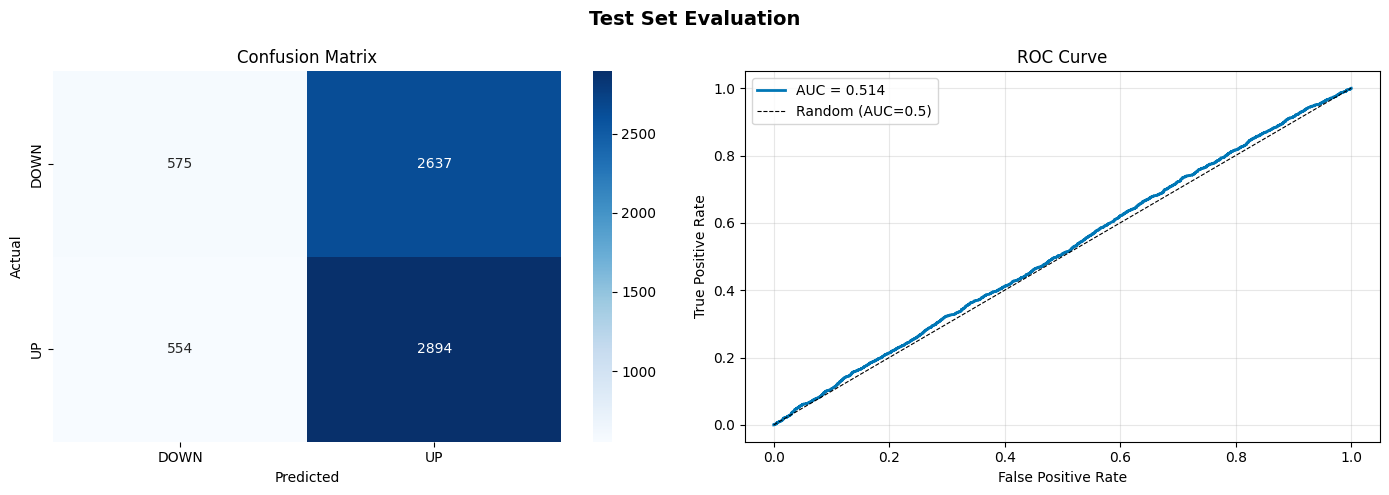

Evaluation charts saved → test_evaluation.png


In [12]:
# Load best checkpoint
model.load_state_dict(torch.load(cfg.CHECKPOINT_PATH, map_location=DEVICE))
print(f"Best model loaded from: {cfg.CHECKPOINT_PATH}\n")

te_loss, te_acc, te_auc, te_f1, te_probs, te_labels = evaluate(model, test_loader, criterion)

print("="*50)
print(" TEST SET RESULTS")
print("="*50)
print(f"  Loss     : {te_loss:.4f}")
print(f"  Accuracy : {te_acc:.4f}")
print(f"  AUC-ROC  : {te_auc:.4f}")
print(f"  F1 Score : {te_f1:.4f}")
print()

te_preds = (te_probs >= 0.5).astype(int)
print(classification_report(te_labels, te_preds, target_names=["DOWN (0)", "UP (1)"]))


def plot_evaluation(labels, probs, preds):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Test Set Evaluation", fontsize=14, fontweight="bold")

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["DOWN", "UP"], yticklabels=["DOWN", "UP"],
                ax=axes[0])
    axes[0].set_title("Confusion Matrix")
    axes[0].set_ylabel("Actual"); axes[0].set_xlabel("Predicted")

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, probs)
    axes[1].plot(fpr, tpr, color="#0077B6", lw=2,
                 label=f"AUC = {te_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=0.8, label="Random (AUC=0.5)")
    axes[1].set_title("ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("test_evaluation.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Evaluation charts saved → test_evaluation.png")


plot_evaluation(te_labels, te_probs, te_preds)


## Cell 13 — Hyperparameter Fine-Tuning Experiments



 Hyperparameter Fine-Tuning Experiments (20 epochs each)
  [Baseline (LR=1e-3)] Val AUC: 0.5122  Acc: 0.5130  F1: 0.6781
  [LR=5e-4] Val AUC: 0.5126  Acc: 0.5041  F1: 0.4242
  [LR=2e-3] Val AUC: 0.5075  Acc: 0.4870  F1: 0.0000
  [LSTM Hidden=64] Val AUC: 0.5107  Acc: 0.4870  F1: 0.0000
  [LSTM Hidden=256] Val AUC: 0.5183  Acc: 0.4875  F1: 0.0035
  [Dropout=0.1] Val AUC: 0.5110  Acc: 0.5127  F1: 0.6747
  [Dropout=0.5] Val AUC: 0.5120  Acc: 0.4962  F1: 0.2604
  [1 Transformer Layer] Val AUC: 0.5135  Acc: 0.4870  F1: 0.0000
  [3 Transformer Layers] Val AUC: 0.5147  Acc: 0.5130  F1: 0.6781
  [Window=20] Val AUC: 0.5091  Acc: 0.4894  F1: 0.0359
  [Window=40] Val AUC: 0.5100  Acc: 0.5131  F1: 0.5419

── Fine-Tuning Results (sorted by Val AUC) ─────────────────
          Experiment  Val Acc  Val AUC   Val F1
     LSTM Hidden=256 0.487481 0.518250 0.003519
3 Transformer Layers 0.512971 0.514691 0.678098
 1 Transformer Layer 0.487029 0.513518 0.000000
             LR=5e-4 0.504072 0.512594 0.4

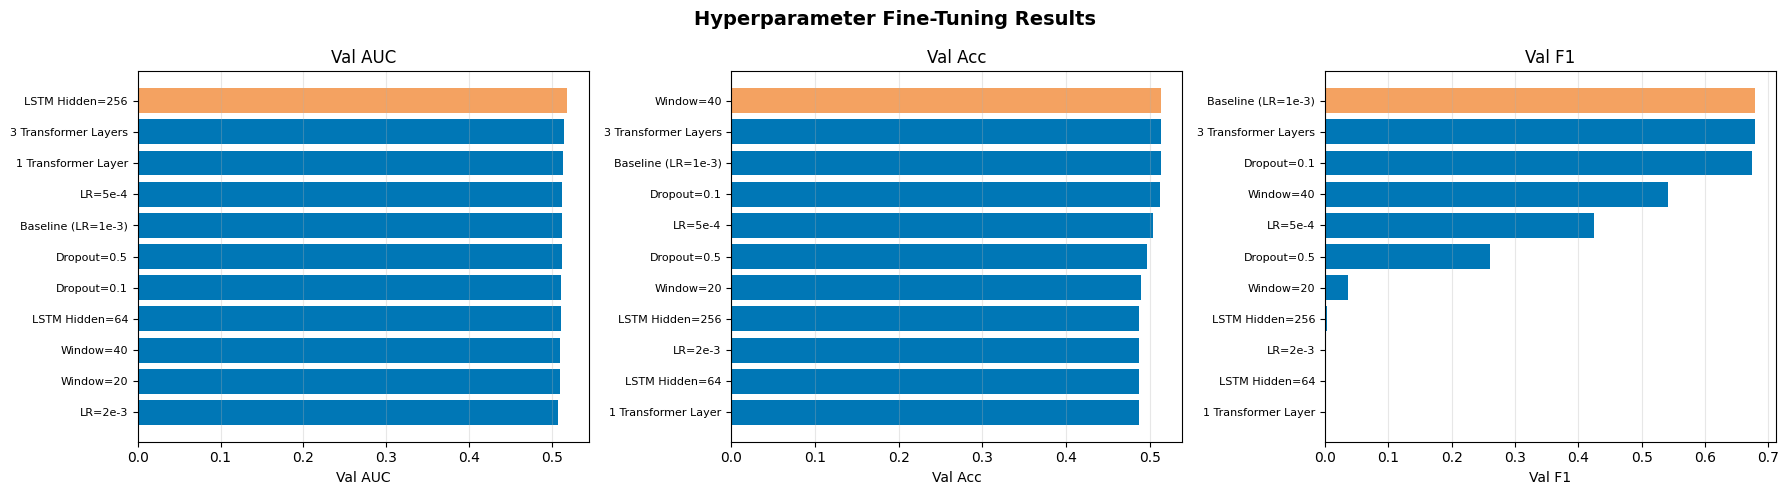

Fine-tuning chart saved → finetuning_results.png


In [13]:
# We systematically vary key hyperparameters and record val AUC.
# This constitutes the "fine-tuning" phase required by the milestone.

def run_experiment(exp_name: str, overrides: dict,
                   train_loader, val_loader, cfg: Config,
                   epochs: int = 20) -> dict:
    """
    Train a model variant with overridden config values.
    Returns a dict of {experiment, val_acc, val_auc, val_f1}.
    """
    # Temporarily apply overrides
    original = {k: getattr(cfg, k) for k in overrides}
    for k, v in overrides.items():
        setattr(cfg, k, v)

    exp_model = HybridLSTMTransformer(cfg).to(DEVICE)
    exp_crit  = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
    exp_opt   = optim.AdamW(exp_model.parameters(), lr=cfg.LEARNING_RATE,
                            weight_decay=cfg.WEIGHT_DECAY)

    best_val_auc = 0.0
    for _ in range(epochs):
        train_one_epoch(exp_model, train_loader, exp_opt, exp_crit)
        _, va, auc, f1, _, _ = evaluate(exp_model, val_loader, exp_crit)
        if auc > best_val_auc:
            best_val_auc = auc
            best_acc, best_f1 = va, f1

    # Restore original config
    for k, v in original.items():
        setattr(cfg, k, v)

    print(f"  [{exp_name}] Val AUC: {best_val_auc:.4f}  Acc: {best_acc:.4f}  F1: {best_f1:.4f}")
    return {"Experiment": exp_name, "Val Acc": best_acc,
            "Val AUC": best_val_auc, "Val F1": best_f1}


print("\n" + "="*60)
print(" Hyperparameter Fine-Tuning Experiments (20 epochs each)")
print("="*60)

experiments = [
    ("Baseline (LR=1e-3)",        {"LEARNING_RATE": 1e-3}),
    ("LR=5e-4",                   {"LEARNING_RATE": 5e-4}),
    ("LR=2e-3",                   {"LEARNING_RATE": 2e-3}),
    ("LSTM Hidden=64",            {"LSTM_HIDDEN": 64,  "TRANSFORMER_DIM": 64}),
    ("LSTM Hidden=256",           {"LSTM_HIDDEN": 256, "TRANSFORMER_DIM": 256}),
    ("Dropout=0.1",               {"LSTM_DROPOUT": 0.1, "TRANSFORMER_DROPOUT": 0.05}),
    ("Dropout=0.5",               {"LSTM_DROPOUT": 0.5, "TRANSFORMER_DROPOUT": 0.2}),
    ("1 Transformer Layer",       {"TRANSFORMER_LAYERS": 1}),
    ("3 Transformer Layers",      {"TRANSFORMER_LAYERS": 3}),
    ("Window=20",                 {"WINDOW_SIZE": 20}),
    ("Window=40",                 {"WINDOW_SIZE": 40}),
]

results = []
for name, overrides in experiments:
    r = run_experiment(name, overrides, train_loader, val_loader, cfg, epochs=20)
    results.append(r)

results_df = pd.DataFrame(results).sort_values("Val AUC", ascending=False)
print("\n── Fine-Tuning Results (sorted by Val AUC) ─────────────────")
print(results_df.to_string(index=False))


def plot_finetuning(results_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Hyperparameter Fine-Tuning Results", fontsize=14, fontweight="bold")

    for ax, metric in zip(axes, ["Val AUC", "Val Acc", "Val F1"]):
        df_sorted = results_df.sort_values(metric, ascending=True)
        colors = ["#0077B6" if i < len(df_sorted) - 1 else "#F4A261"
                  for i in range(len(df_sorted))]
        ax.barh(df_sorted["Experiment"], df_sorted[metric],
                color=colors, edgecolor="none")
        ax.set_title(metric)
        ax.set_xlabel(metric)
        ax.grid(axis="x", alpha=0.3)
        ax.tick_params(axis="y", labelsize=8)

    plt.tight_layout()
    plt.savefig("finetuning_results.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Fine-tuning chart saved → finetuning_results.png")


plot_finetuning(results_df)


## Cell 14 — Attention Weight Visualisation (Explainability)


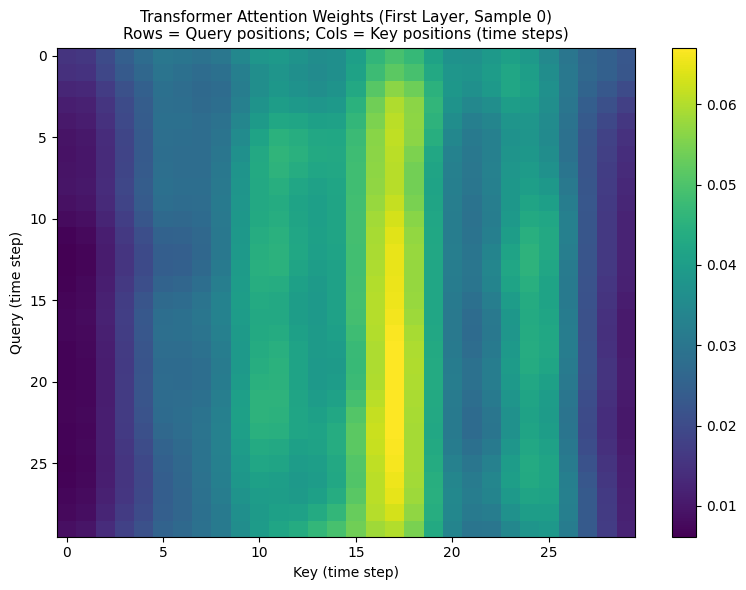

Attention weight map saved → attention_weights.png


In [14]:
def get_attention_weights(model: nn.Module, x: torch.Tensor) -> np.ndarray:
    """
    Extract averaged attention weights from the first Transformer layer.
    Returns a (seq_len, seq_len) attention matrix.
    """
    model.eval()
    attn_weights = []

    def hook_fn(module, input, output):
        # TransformerEncoderLayer output is just the tensor, not the weights
        # We re-run attention manually for visualisation
        pass

    with torch.no_grad():
        x = x.to(DEVICE)
        # Get LSTM output
        proj = model.input_proj(x)
        lstm_out, _ = model.lstm(proj)
        t_in = model.lstm_proj(lstm_out)
        t_in = model.pos_enc(t_in)

        # Extract attention from first layer manually
        layer = model.transformer.layers[0]
        # Self-attention with weight return
        attn_out, attn_w = layer.self_attn(
            t_in, t_in, t_in, need_weights=True, average_attn_weights=True
        )

    return attn_w.cpu().numpy()   # (batch, seq_len, seq_len)


# Visualise for first sample in test set
x_sample, y_sample = next(iter(test_loader))
attn_matrix = get_attention_weights(model, x_sample[:1])  # (1, T, T)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(attn_matrix[0], aspect="auto", cmap="viridis", origin="upper")
plt.colorbar(im, ax=ax)
ax.set_title("Transformer Attention Weights (First Layer, Sample 0)\n"
             "Rows = Query positions; Cols = Key positions (time steps)", fontsize=11)
ax.set_xlabel("Key (time step)")
ax.set_ylabel("Query (time step)")
plt.tight_layout()
plt.savefig("attention_weights.png", dpi=120, bbox_inches="tight")
plt.show()
print("Attention weight map saved → attention_weights.png")


## Cell 15 — Baseline Comparisons


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.dummy import DummyClassifier

print("\n── Baseline Model Comparisons ──────────────────────────────")

# Flatten sequences to 2-D for sklearn models
def flatten_loader(loader):
    Xs, ys = [], []
    for X, y in loader:
        Xs.append(X.numpy().reshape(len(X), -1))
        ys.append(y.numpy())
    return np.vstack(Xs), np.concatenate(ys)

X_train_flat, y_train_flat = flatten_loader(train_loader)
X_test_flat,  y_test_flat  = flatten_loader(test_loader)

baselines = {
    "Random (Dummy)": DummyClassifier(strategy="most_frequent"),
    "XGBoost-like (GBT)": GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                                       learning_rate=0.1, random_state=42),
}

comparison_rows = []
for name, clf in baselines.items():
    clf.fit(X_train_flat, y_train_flat)
    preds = clf.predict(X_test_flat)
    proba = clf.predict_proba(X_test_flat)[:, 1] if hasattr(clf, "predict_proba") else preds
    acc  = accuracy_score(y_test_flat, preds)
    auc  = roc_auc_score(y_test_flat, proba) if len(set(proba)) > 1 else 0.5
    f1   = f1_score(y_test_flat, preds, zero_division=0)
    print(f"  {name:<30} Acc: {acc:.4f}  AUC: {auc:.4f}  F1: {f1:.4f}")
    comparison_rows.append({"Model": name, "Acc": acc, "AUC": auc, "F1": f1})

# Add our model
comparison_rows.append({
    "Model": "Hybrid LSTM-Transformer (Ours)",
    "Acc": te_acc, "AUC": te_auc, "F1": te_f1
})
comparison_df = pd.DataFrame(comparison_rows)
print("\n── Final Model Comparison Table ─────────────────────────────")
print(comparison_df.to_string(index=False))


def plot_comparison(comparison_df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Model Comparison on Test Set", fontsize=14, fontweight="bold")
    palette = ["#ADB5BD"] * (len(comparison_df) - 1) + ["#0077B6"]

    for ax, metric in zip(axes, ["Acc", "AUC", "F1"]):
        ax.bar(comparison_df["Model"], comparison_df[metric],
               color=palette, edgecolor="none")
        ax.set_title(f"Test {metric}")
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1.0)
        ax.axhline(0.5, color="gray", ls="--", lw=0.8)
        ax.tick_params(axis="x", rotation=25, labelsize=8)
        ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Comparison chart saved → model_comparison.png")


plot_comparison(comparison_df)



── Baseline Model Comparisons ──────────────────────────────
  Random (Dummy)                 Acc: 0.5177  AUC: 0.5000  F1: 0.6822


## Cell 16 — Save Final Model & Artefacts


In [ ]:
import json

# Save model
torch.save(model.state_dict(), "final_model.pt")
print("Final model saved → final_model.pt")

# Save training history
with open("training_history.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.items()}, f, indent=2)
print("Training history saved → training_history.json")

# Save comparison table
comparison_df.to_csv("model_comparison.csv", index=False)
print("Model comparison saved → model_comparison.csv")

# Summary
print("\n" + "="*65)
print(" MILESTONE 2 — SUMMARY")
print("="*65)
print(f"  Dataset       : S&P 500 ({len(processed_data)} tickers, Kaggle)")
print(f"  Features      : {cfg.INPUT_DIM} (OHLCV + 7 technical indicators)")
print(f"  Window Size   : {cfg.WINDOW_SIZE} days")
print(f"  Model         : Hybrid Bidirectional LSTM + Transformer")
print(f"  Parameters    : {trainable:,}")
print(f"  Training Stop : Epoch {len(history['val_loss'])} (early stopping)")
print(f"  Test Accuracy : {te_acc:.4f}")
print(f"  Test AUC-ROC  : {te_auc:.4f}")
print(f"  Test F1       : {te_f1:.4f}")
print("="*65)
print("\nAll artefacts saved. Please upload this .py file and your Colab link to Moodle.")
